# Rutherford Scattering and the Nuclear Atom

The Geiger-Marsden gold-foil experiment forced a change in the atomic picture. If positive charge were spread through the atom, as in Thomson's plum-pudding model, energetic alpha particles should suffer only gentle deflections. Instead, a small but unmistakable fraction scattered through very large angles, including near-backward events.

Rutherford's explanation: the alpha particle does not feel a diffuse charge cloud. It feels a compact, heavy, positively charged nucleus, so the collision is well described by classical Coulomb scattering from a point-like center.

A beam of alpha particles with charge $z = 2$ and mass $m_{\alpha}$ is sent toward a thin gold foil with nuclear charge $Z = 79$. Most particles pass through with almost no deflection, which already tells us the atom is mostly empty space. The surprise is the rare tail of very large-angle events.

Those rare events are the decisive clue. A large deflection requires the alpha particle to come close to a concentrated positive charge, so the data point toward a very small nuclear core rather than a smeared-out positive medium.

## Beam, potential, and symbols

For a nucleus treated as fixed in space, the alpha particle moves in the repulsive Coulomb potential

$$
V(r) = \frac{Z z e^2}{4 \pi \varepsilon_0 r} \equiv \frac{\kappa}{r},
\qquad
\kappa := \frac{Z z e^2}{4 \pi \varepsilon_0}.
$$

If the incident beam energy is $E = \tfrac12 m_{\alpha} v^2$, then the incoming state is specified by the speed $v$ and the impact parameter $b$, the miss distance the particle would have had far from the target in the absence of a force.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

e = 1.602176634e-19
epsilon0 = 8.8541878128e-12
m_alpha = 6.644657e-27
N_A = 6.02214076e23

Z_AU = 79
A_AU = 197

def mev_to_joule(energy_mev):
    return energy_mev * 1e6 * e

def kappa(Z, z=2):
    return Z * z * e**2 / (4 * np.pi * epsilon0)

def theta_from_b(b, E, Z, z=2):
    return 2 * np.arctan(kappa(Z, z) / (2 * E * b))

def b_from_theta(theta, E, Z, z=2):
    return (kappa(Z, z) / (2 * E)) / np.tan(theta / 2)

def rutherford_dsigma_domega(theta, E, Z, z=2):
    return (kappa(Z, z) / (4 * E))**2 / np.sin(theta / 2)**4

def sigma_greater_than(theta0, E, Z, z=2):
    return np.pi * b_from_theta(theta0, E, Z, z)**2

def gold_number_density():
    rho = 19.32e3
    molar_mass = 196.96657e-3
    return rho * N_A / molar_mass

def thomas_fermi_screen_length(Z):
    a0 = 5.29177210903e-11
    return 0.8853 * a0 / (Z ** (1 / 3))

def nuclear_radius(A):
    return 1.2e-15 * A ** (1 / 3)

E_MEV = 5.0
E = mev_to_joule(E_MEV)

print(f"Using E = {E_MEV:.1f} MeV alpha particles on gold.")
print(f"kappa = {kappa(Z_AU):.3e} J m")

Using E = 5.0 MeV alpha particles on gold.
kappa = 3.645e-26 J m


## From impact parameter to scattering angle

For Coulomb scattering the trajectory is a hyperbola. Conservation of energy and angular momentum leads to the key relation

$$
\tan\frac{\theta}{2} = \frac{\kappa}{2 E b},
\qquad
b(\theta) = \frac{\kappa}{2 E} \cot\frac{\theta}{2}.
$$

This is the central geometric link in Rutherford's argument. Small impact parameter means a closer encounter and therefore a larger deflection angle.

A useful checkpoint is the special case $\theta = 90^\circ$. Then $\tan(\theta/2) = 1$, so the characteristic impact parameter is simply $b_{90} = \kappa / (2E)$. That scale separates glancing encounters from the rarer, more violent deflections.

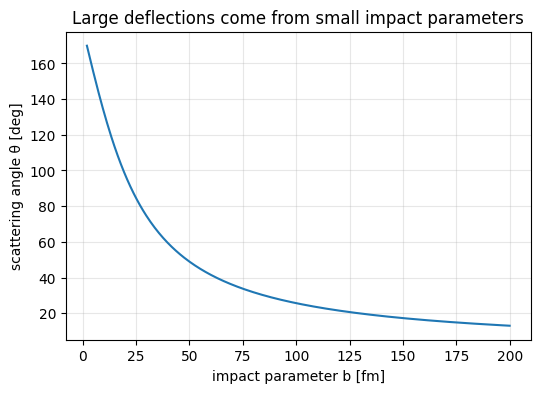

b_90 = 22.75 fm for E = 5.0 MeV


In [20]:
b_vals = np.linspace(2e-15, 2e-13, 400)
theta_vals = theta_from_b(b_vals, E, Z_AU)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(b_vals * 1e15, np.degrees(theta_vals), color="tab:blue")
ax.set_xlabel("impact parameter b [fm]")
ax.set_ylabel("scattering angle θ [deg]")
ax.set_title("Large deflections come from small impact parameters")
ax.grid(alpha=0.3)
plt.show()

b_90 = kappa(Z_AU) / (2 * E)
print(f"b_90 = {b_90 * 1e15:.2f} fm for E = {E_MEV:.1f} MeV")

## A numerical trajectory check

The analytic angle formula is exact for a pure Coulomb force, but it is useful to see the geometry directly. The next cells integrate Newton's equation for several impact parameters and compare the numerically measured scattering angle with the analytic prediction.

In [21]:
def coulomb_acceleration(position, Z, z=2):
    radius = np.linalg.norm(position)
    return kappa(Z, z) * position / (m_alpha * radius**3)

def integrate_trajectory(b, E, Z, z=2, z_start=-4e-13, dt=2e-23, max_steps=50000):
    speed = np.sqrt(2 * E / m_alpha)
    position = np.array([b, 0.0, z_start], dtype=float)
    velocity = np.array([0.0, 0.0, speed], dtype=float)
    points = [position.copy()]

    for _ in range(max_steps):
        velocity = velocity + coulomb_acceleration(position, Z, z) * dt
        position = position + velocity * dt
        points.append(position.copy())
        if position[2] > abs(z_start):
            break

    direction = velocity / np.linalg.norm(velocity)
    theta = np.arccos(np.clip(direction[2], -1.0, 1.0))
    return np.array(points), theta

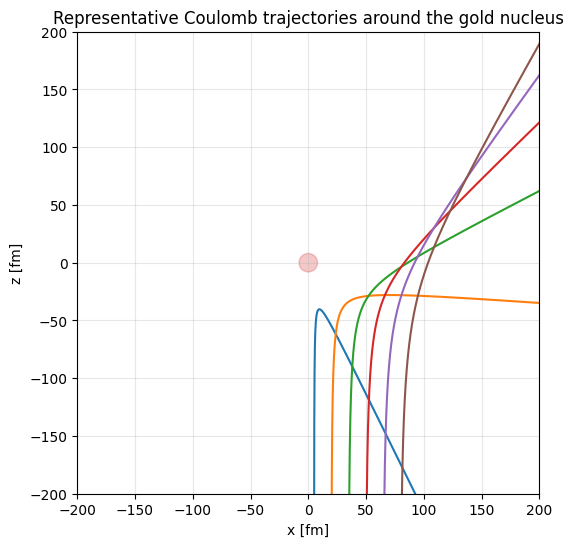

In [22]:
impact_parameters = np.linspace(5e-15, 8e-14, 6)

fig, ax = plt.subplots(figsize=(6, 6))
for b in impact_parameters:
    path, _ = integrate_trajectory(b, E, Z_AU)
    ax.plot(path[:, 0] * 1e15, path[:, 2] * 1e15)

ax.add_patch(Circle((0.0, 0.0), 8.0, color="tab:red", alpha=0.25))
ax.set_xlabel("x [fm]")
ax.set_ylabel("z [fm]")
ax.set_title("Representative Coulomb trajectories around the gold nucleus")
ax.set_aspect("equal")
ax.grid(alpha=0.3)
ax.set_xlim(-200, 200)
ax.set_ylim(-200, 200)
plt.show()

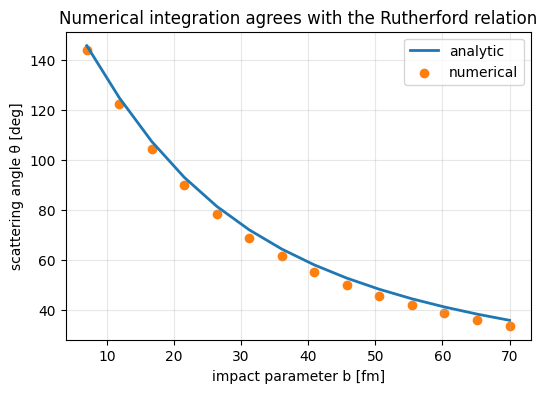

In [23]:
b_samples = np.linspace(7e-15, 7e-14, 14)
theta_numeric = np.array([integrate_trajectory(b, E, Z_AU)[1] for b in b_samples])
theta_exact = theta_from_b(b_samples, E, Z_AU)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(b_samples * 1e15, np.degrees(theta_exact), label="analytic", linewidth=2)
ax.scatter(b_samples * 1e15, np.degrees(theta_numeric), label="numerical", color="tab:orange")
ax.set_xlabel("impact parameter b [fm]")
ax.set_ylabel("scattering angle θ [deg]")
ax.set_title("Numerical integration agrees with the Rutherford relation")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Thin foils and large-angle counts

Integrating over all angles above a threshold $\theta_0$ gives

$$
\sigma(>\theta_0) = \pi b(\theta_0)^2 = \pi \left(\frac{\kappa}{2E}\right)^2 \cot^2\frac{\theta_0}{2}.
$$

For a foil with atomic number density $n$ and thickness $t$, the mean number of scatters above that threshold is

$$
\mu(>\theta_0) = n t \, \sigma(>\theta_0).
$$

When $\mu \ll 1$, multiple scattering is rare and the simple Rutherford picture is internally consistent.

In [24]:
n_au = gold_number_density()
theta0 = np.radians(20.0)
sigma20 = sigma_greater_than(theta0, E, Z_AU)

print(f"Gold number density: {n_au:.3e} m^-3")
print(f"sigma(theta > 20 deg): {sigma20:.3e} m^2")

for thickness_nm in [10, 50, 100, 500]:
    thickness = thickness_nm * 1e-9
    mu = n_au * thickness * sigma20
    print(f"t = {thickness_nm:>3} nm -> mu = {mu:.3e}")

Gold number density: 5.907e+28 m^-3
sigma(theta > 20 deg): 5.230e-26 m^2
t =  10 nm -> mu = 3.090e-05
t =  50 nm -> mu = 1.545e-04
t = 100 nm -> mu = 3.090e-04
t = 500 nm -> mu = 1.545e-03


For a sufficiently thin foil, $\mu$ stays well below unity, so most projectiles undergo either no large-angle scattering or just one such event. That is the regime in which the Rutherford formula can be compared cleanly with experiment.

## Monte Carlo sampling in impact-parameter space

A clean numerical check is to sample impact parameters uniformly in area and convert each sample to a scattering angle using the analytic map $b \mapsto \theta$. If we histogram the result in $\theta$, the expected shape is not just $d\sigma/d\Omega$; it is proportional to $(d\sigma/d\Omega) \sin\theta$, because a $\theta$ histogram compresses over azimuthal angle.

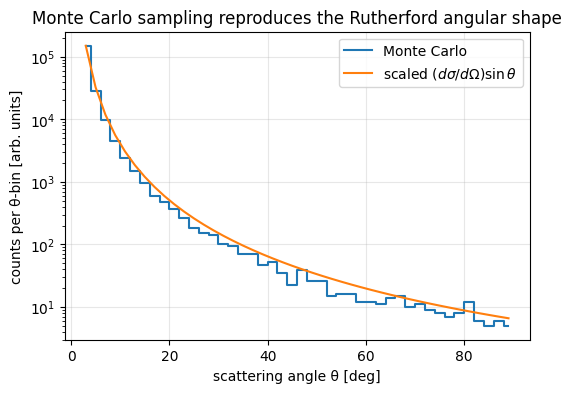

In [25]:
rng = np.random.default_rng(7)

def sample_thetas_via_area(n_samples, E, Z, theta_min_deg=2.0, theta_max_deg=90.0):
    theta_min = np.radians(theta_min_deg)
    theta_max = np.radians(theta_max_deg)
    b_min = b_from_theta(theta_max, E, Z)
    b_max = b_from_theta(theta_min, E, Z)
    u = rng.random(n_samples)
    b = np.sqrt(b_min**2 + u * (b_max**2 - b_min**2))
    return theta_from_b(b, E, Z)

theta_samples = sample_thetas_via_area(200000, E, Z_AU)
bin_edges = np.radians(np.linspace(2.0, 90.0, 45))
counts, edges = np.histogram(theta_samples, bins=bin_edges)
centres = 0.5 * (edges[1:] + edges[:-1])

theta_density = rutherford_dsigma_domega(centres, E, Z_AU) * np.sin(centres)
theta_density *= counts.max() / theta_density.max()

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(np.degrees(centres), counts + 1, drawstyle="steps-mid", label="Monte Carlo")
ax.semilogy(np.degrees(centres), theta_density + 1, label=r"scaled $(d\sigma/d\Omega)\sin\theta$")
ax.set_xlabel("scattering angle θ [deg]")
ax.set_ylabel("counts per θ-bin [arb. units]")
ax.set_title("Monte Carlo sampling reproduces the Rutherford angular shape")
ax.legend()
ax.grid(alpha=0.3)
plt.show()